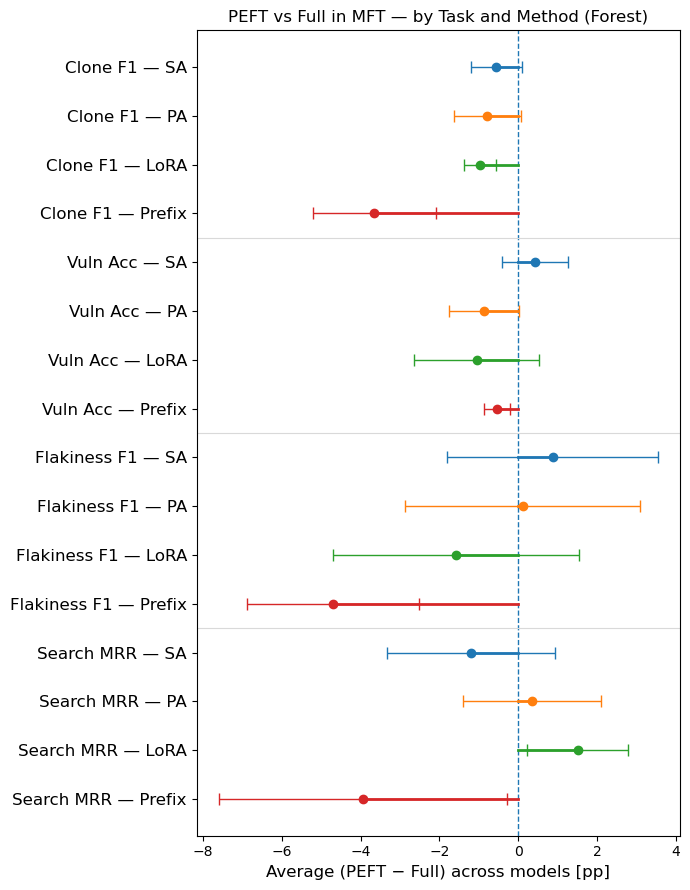

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---- Data (MFT only) ----
records = []
def add(model, method, trainable_pct, clone_f1, vuln_acc, flakiness_f1, search_mrr):
    records.append({
        "model": model, "method": method, "trainable_pct": trainable_pct,
        "Clone F1": clone_f1, "Vuln Acc": vuln_acc, "Flakiness F1": flakiness_f1, "Search MRR": search_mrr
    })

# Unixcoder-base
add("Unixcoder-base","Full",100.00,93.70,61.35,71.20,32.94)
add("Unixcoder-base","Serial adapter",1.85,93.79,61.35,71.90,33.49)
add("Unixcoder-base","Parallel adapter",0.93,92.29,61.05,68.65,32.50)
add("Unixcoder-base","LoRA",0.46,92.33,60.43,66.20,34.81)
add("Unixcoder-base","Prefix",6.43,90.85,60.98,65.38,30.86)

# Codet5+ 770M
add("Codet5+ 770M","Full",100.00,93.68,61.79,72.24,21.64)
add("Codet5+ 770M","Serial adapter",1.70,92.28,63.47,69.80,17.40)
add("Codet5+ 770M","Parallel adapter",0.85,92.24,60.87,70.00,20.01)
add("Codet5+ 770M","LoRA",0.42,92.56,62.12,69.80,22.21)
add("Codet5+ 770M","Prefix",6.43,89.23,61.09,68.65,15.83)

# Deepseek coder 1.3B
add("Deepseek coder 1.3B","Full",100.00,93.31,60.53,68.71,30.70)
add("Deepseek coder 1.3B","Serial adapter",0.98,92.57,60.43,69.69,30.83)
add("Deepseek coder 1.3B","Parallel adapter",0.84,93.72,60.40,70.18,33.20)
add("Deepseek coder 1.3B","LoRA",0.24,92.31,60.25,67.13,33.90)

# Qwen2.5-Coder-1.5B
add("Qwen2.5-Coder-1.5B","Full",100.00,92.86,60.76,68.31,31.06)
add("Qwen2.5-Coder-1.5B","Serial adapter",0.71,92.68,60.87,72.54,29.80)
add("Qwen2.5-Coder-1.5B","Parallel adapter",0.35,92.17,58.64,72.08,32.06)
add("Qwen2.5-Coder-1.5B","LoRA",0.14,92.47,57.39,70.97,31.43)

df = pd.DataFrame.from_records(records)
metrics = ["Clone F1","Vuln Acc","Flakiness F1","Search MRR"]

# ---- Δ vs Full per model & task ----
full = df[df["method"]=="Full"].set_index("model")[metrics]
rows = []
for _, r in df.iterrows():
    if r["method"] == "Full":
        continue
    for m in metrics:
        base = full.loc[r["model"], m]
        val  = r[m]
        if pd.notna(val) and pd.notna(base):
            rows.append({"task": m, "method": r["method"], "model": r["model"], "delta": float(val - base)})
long = pd.DataFrame(rows)

# ---- Aggregate: mean & 95% CI per (task, method) ----
grp = long.groupby(["task","method"])["delta"]
agg = pd.DataFrame({
    "mean": grp.mean(),
    "n": grp.count(),
    "sd": grp.std(ddof=1)
}).reset_index()
agg["ci95"] = np.where(agg["n"] > 1, 1.96 * (agg["sd"] / np.sqrt(agg["n"])), np.nan)

# ---- Ordering & short labels ----
task_order   = ["Search MRR","Flakiness F1","Vuln Acc","Clone F1"]     # top → bottom blocks
method_order = ["Prefix","LoRA","Parallel adapter","Serial adapter"]    # within each task

short = {"Serial adapter":"SA","Parallel adapter":"PA","LoRA":"LoRA","Prefix":"Prefix"}

agg["task"]   = pd.Categorical(agg["task"], categories=task_order, ordered=True)
agg["method"] = pd.Categorical(agg["method"], categories=method_order, ordered=True)
agg = agg.sort_values(["task","method"]).reset_index(drop=True)

labels = [f"{t} — {short[m]}" for t, m in zip(agg["task"], agg["method"])]
means  = agg["mean"].to_numpy()
cis    = agg["ci95"].to_numpy()
methods_for_rows = agg["method"].astype(str).tolist()

# ---- Fixed colors per method (consistent across tasks) ----
color_map = {
    "Serial adapter":  "#1f77b4",  # SA
    "Parallel adapter":"#ff7f0e",  # PA
    "LoRA":            "#2ca02c",
    "Prefix":          "#d62728",
}

# ---- Plot: forest/lollipop (consistent colors) ----
plt.figure(figsize=(7,9))
y = np.arange(len(labels))

plt.axvline(0, linestyle="--", linewidth=1)  # baseline = Full

for i, (mu, ci) in enumerate(zip(means, cis)):
    method_i = methods_for_rows[i]
    col = color_map[method_i]
    # stem + head in the method's color
    plt.plot([0, mu], [i, i], linewidth=2, color=col)
    plt.plot(mu, i, "o", markersize=6, color=col)
    if np.isfinite(ci):
        plt.errorbar(mu, i, xerr=ci, fmt="none", capsize=4, linewidth=1, color=col, ecolor=col)

# faint separators between task blocks
block = len(method_order)
for k in range(1, len(task_order)):
    plt.axhline(k*block - 0.5, color="0.85", linewidth=0.8)

plt.yticks(y, labels =labels, fontsize=12)
plt.xlabel("Average (PEFT − Full) across models [pp]" , fontsize=12)
plt.title("PEFT vs Full in MFT — by Task and Method (Forest)" , fontsize=12)

# Legend keyed to methods (short labels)
legend_handles = [
    Line2D([0],[0], color=color_map[m], lw=3, label=short[m])
    for m in method_order
]
#plt.legend(handles=legend_handles, title="PEFT method", loc="lower right")

plt.tight_layout()
# plt.savefig("RQ1_MFT_Forest_Task_by_Method_consistent_colors.png", dpi=300)
# plt.show()


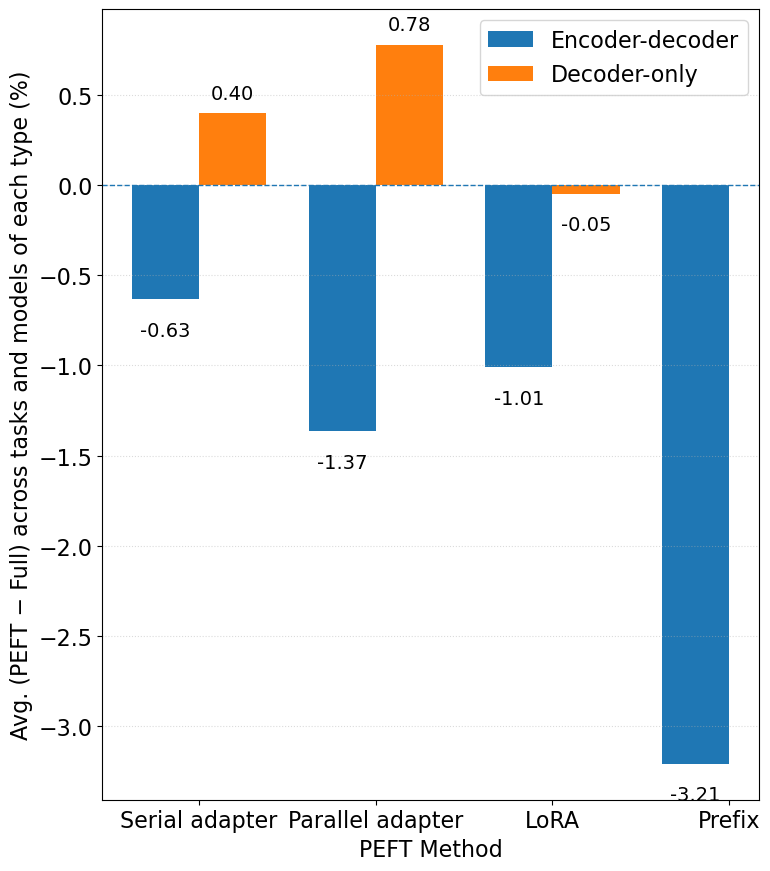

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- nicer, larger typography ----------
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
})

# ---------- data (MFT only) ----------
records = []
def add(model, method, trainable_pct, clone_f1, vuln_acc, flakiness_f1, search_mrr):
    records.append({
        "model": model, "method": method, "trainable_pct": trainable_pct,
        "Clone F1": clone_f1, "Vuln Acc": vuln_acc, "Flakiness F1": flakiness_f1, "Search MRR": search_mrr
    })

# Unixcoder-base
add("Unixcoder-base","Full",100.00,93.70,61.35,71.20,32.94)
add("Unixcoder-base","Serial adapter",1.85,93.79,61.35,71.90,33.49)
add("Unixcoder-base","Parallel adapter",0.93,92.29,61.05,68.65,32.50)
add("Unixcoder-base","LoRA",0.46,92.33,60.43,66.20,34.81)
add("Unixcoder-base","Prefix",6.43,90.85,60.98,65.38,30.86)

# Codet5+ 770M
add("Codet5+ 770M","Full",100.00,93.68,61.79,72.24,21.64)
add("Codet5+ 770M","Serial adapter",1.70,92.28,63.47,69.80,17.40)
add("Codet5+ 770M","Parallel adapter",0.85,92.24,60.87,70.00,20.01)
add("Codet5+ 770M","LoRA",0.42,92.56,62.12,69.80,22.21)
add("Codet5+ 770M","Prefix",6.43,89.23,61.09,68.65,15.83)

# Deepseek coder 1.3B
add("Deepseek coder 1.3B","Full",100.00,93.31,60.53,68.71,30.70)
add("Deepseek coder 1.3B","Serial adapter",0.98,92.57,60.43,69.69,30.83)
add("Deepseek coder 1.3B","Parallel adapter",0.84,93.72,60.40,70.18,33.20)
add("Deepseek coder 1.3B","LoRA",0.24,92.31,60.25,67.13,33.90)

# Qwen2.5-Coder-1.5B
add("Qwen2.5-Coder-1.5B","Full",100.00,92.86,60.76,68.31,31.06)
add("Qwen2.5-Coder-1.5B","Serial adapter",0.71,92.68,60.87,72.54,29.80)
add("Qwen2.5-Coder-1.5B","Parallel adapter",0.35,92.17,58.64,72.08,32.06)
add("Qwen2.5-Coder-1.5B","LoRA",0.14,92.47,57.39,70.97,31.43)

df = pd.DataFrame.from_records(records)
metrics = ["Clone F1", "Vuln Acc", "Flakiness F1", "Search MRR"]

# ---------- Δ vs Full per model & task, then macro-average across tasks ----------
full = df[df["method"]=="Full"].set_index("model")[metrics]
for m in metrics:
    df[f"Δ {m} vs Full (pp)"] = df.apply(
        lambda r: np.nan if pd.isna(r[m]) else r[m] - full.loc[r["model"], m],
        axis=1
    )
df["Macro Δ vs Full (pp)"] = df[[f"Δ {m} vs Full (pp)" for m in metrics]].mean(axis=1, skipna=True)

# Model-type groups
group_map = {
    "Unixcoder-base": "Encoder-decoder",
    "Codet5+ 770M": "Encoder-decoder",
    "Deepseek coder 1.3B": "Decoder-only",
    "Qwen2.5-Coder-1.5B": "Decoder-only",
}
df["Model type"] = df["model"].map(group_map)

# ---------- aggregate for the plot (MFT, PEFT only) ----------
mft = df[df["method"]!="Full"]
agg = (
    mft.groupby(["method","Model type"])["Macro Δ vs Full (pp)"]
    .mean()
    .unstack("Model type")
    .reindex(index=["Serial adapter","Parallel adapter","LoRA","Prefix"])
    .reindex(columns=["Encoder-decoder","Decoder-only"])
)

# Optional: short method names (SA/PA)
USE_SHORT_NAMES = False   # set True to shorten labels
if USE_SHORT_NAMES:
    index_map = {
        "Serial adapter": "SA",
        "Parallel adapter": "PA",
        "LoRA": "LoRA",
        "Prefix": "Prefix",
    }
    agg.index = [index_map[i] for i in agg.index]

# ---------- plot (square layout, clearer labels) ----------
fig = plt.figure(figsize=(8, 9))  # square layout
ax = plt.gca()

x = np.arange(len(agg.index))
width = 0.38

bars_enc = ax.bar(x - width/2, agg["Encoder-decoder"].values, width, label="Encoder-decoder")
bars_dec = ax.bar(x + width/2, agg["Decoder-only"].values, width, label="Decoder-only")

# 0-baseline to indicate parity with Full
ax.axhline(0, linestyle="--", linewidth=1)

# axis labels: simple and explicit
ax.set_xlabel("PEFT Method")
ax.set_ylabel("Avg. (PEFT − Full) across tasks and models of each type (%)")
ax.set_title("")

# x ticks
ax.set_xticks(x)
ax.set_xticklabels(agg.index)

# annotate values on bars
def annotate(bars):
    for b in bars:
        h = b.get_height()
        if np.isnan(h):
            continue
        ax.text(
            b.get_x() + b.get_width()/2,
            h + (0.06 if h >= 0 else -0.12),
            f"{h:.2f}",
            ha="center", va="bottom" if h >= 0 else "top", fontsize=14
        )

annotate(bars_enc)
annotate(bars_dec)

ax.legend(loc="upper right", frameon=True)
ax.grid(axis="y", linestyle=":", alpha=0.45)

fig.tight_layout()
# plt.savefig("RQ1_MFT_Method_by_ModelType_square.png", dpi=300)
# plt.show()


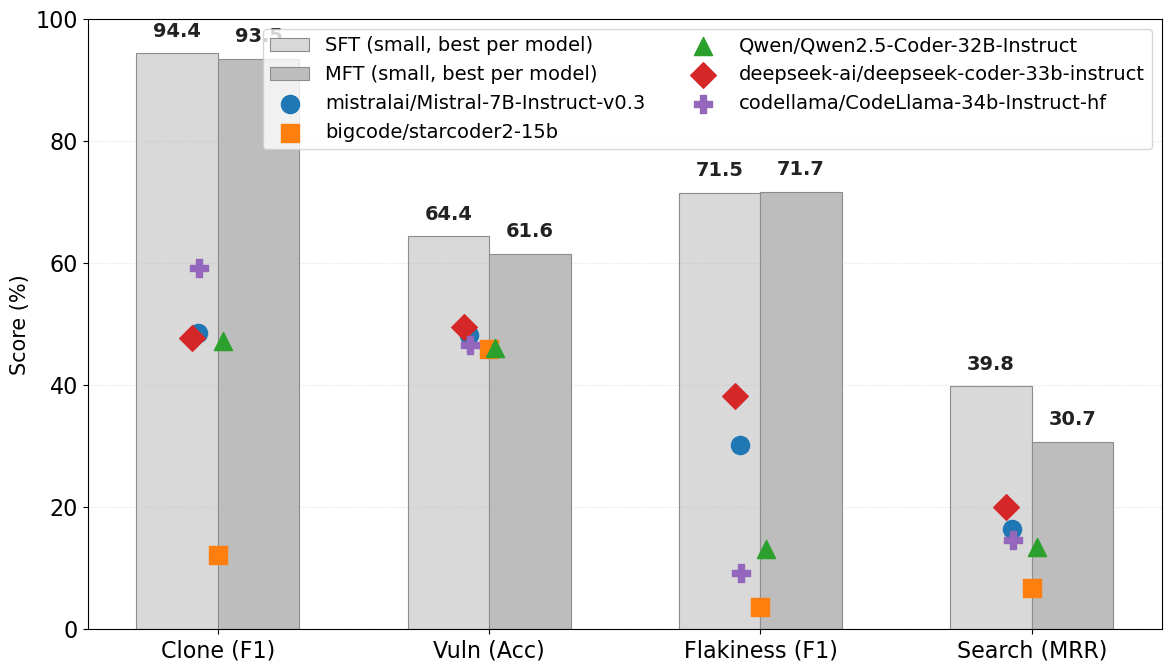

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



# -----------------------------
# 1) Fine-tuning results (MFT/SFT)
# -----------------------------
records = []
def add(setting, model, method, clone_f1, vuln_acc, flakiness_f1, search_mrr):
    records.append({
        "setting": setting, "model": model, "method": method,
        "Clone F1": clone_f1, "Vuln Acc": vuln_acc, "Flakiness F1": flakiness_f1, "Search MRR": search_mrr
    })

# MFT
add("MFT","Unixcoder-base","Full",93.70,61.35,71.20,32.94)
add("MFT","Unixcoder-base","Serial adapter",93.79,61.35,71.90,33.49)
add("MFT","Unixcoder-base","Parallel adapter",92.29,61.05,68.65,32.50)
add("MFT","Unixcoder-base","LoRA",92.33,60.43,66.20,34.81)
add("MFT","Unixcoder-base","Prefix",90.85,60.98,65.38,30.86)

add("MFT","Codet5+ 770M","Full",93.68,61.79,72.24,21.64)
add("MFT","Codet5+ 770M","Serial adapter",92.28,63.47,69.80,17.40)
add("MFT","Codet5+ 770M","Parallel adapter",92.24,60.87,70.00,20.01)
add("MFT","Codet5+ 770M","LoRA",92.56,62.12,69.80,22.21)
add("MFT","Codet5+ 770M","Prefix",89.23,61.09,68.65,15.83)

add("MFT","Deepseek coder 1.3B","Full",93.31,60.53,68.71,30.70)
add("MFT","Deepseek coder 1.3B","Serial adapter",92.57,60.43,69.69,30.83)
add("MFT","Deepseek coder 1.3B","Parallel adapter",93.72,60.40,70.18,33.20)
add("MFT","Deepseek coder 1.3B","LoRA",92.31,60.25,67.13,33.90)

add("MFT","Qwen2.5-Coder-1.5B","Full",92.86,60.76,68.31,31.06)
add("MFT","Qwen2.5-Coder-1.5B","Serial adapter",92.68,60.87,72.54,29.80)
add("MFT","Qwen2.5-Coder-1.5B","Parallel adapter",92.17,58.64,72.08,32.06)
add("MFT","Qwen2.5-Coder-1.5B","LoRA",92.47,57.39,70.97,31.43)

# SFT
add("SFT","Unixcoder-base","Full",94.34,65.19,73.93,33.51)
add("SFT","Unixcoder-base","Serial adapter",94.71,63.07,69.45,36.68)
add("SFT","Unixcoder-base","Parallel adapter",94.36,64.86,67.58,35.31)
add("SFT","Unixcoder-base","LoRA",93.84,62.59,66.22,37.28)
add("SFT","Unixcoder-base","Prefix",92.75,62.41,68.73,38.10)

add("SFT","Codet5+ 770M","Full",94.73,65.37,69.57,35.41)
add("SFT","Codet5+ 770M","Serial adapter",93.90,65.48,68.87,37.13)
add("SFT","Codet5+ 770M","Parallel adapter",94.41,64.20,69.08,36.47)
add("SFT","Codet5+ 770M","LoRA",93.99,63.56,70.21,37.70)
add("SFT","Codet5+ 770M","Prefix",90.35,56.30,56.92,28.27)

add("SFT","Deepseek coder 1.3B","Full",93.10,62.96,66.41,27.92)
add("SFT","Deepseek coder 1.3B","Serial adapter",93.38,63.87,71.63,41.76)
add("SFT","Deepseek coder 1.3B","Parallel adapter",93.50,63.62,68.69,36.55)
add("SFT","Deepseek coder 1.3B","LoRA",93.75,63.73,66.90,43.57)

add("SFT","Qwen2.5-Coder-1.5B","Full",94.23,63.18,67.88,29.80)
add("SFT","Qwen2.5-Coder-1.5B","Serial adapter",94.43,62.70,69.90,39.82)
add("SFT","Qwen2.5-Coder-1.5B","Parallel adapter",94.08,62.77,70.42,37.26)
add("SFT","Qwen2.5-Coder-1.5B","LoRA",93.99,62.85,69.82,39.81)

ft = pd.DataFrame.from_records(records)
tasks = ["Clone F1","Vuln Acc","Flakiness F1","Search MRR"]
best = ft.groupby(["setting","model"])[tasks].max().reset_index()
avg_by_setting_task = best.groupby("setting")[tasks].mean()

# -----------------------------
# 2) Direct prompting (pour les points)
# -----------------------------
prompt_rows = [
    ("mistralai/Mistral-7B-Instruct-v0.3",           7, 48.6, 48.17, 30.25, 16.43),
    ("bigcode/starcoder2-15b",                      15, 12.14, 45.94,  3.58,  6.82),
    ("Qwen/Qwen2.5-Coder-32B-Instruct",             32, 47.22, 46.16, 13.18, 13.54),
    ("deepseek-ai/deepseek-coder-33b-instruct",     33, 47.66, 49.49, 38.25, 20.10),
    ("codellama/CodeLlama-34b-Instruct-hf",         34, 59.12, 46.52,  9.18, 14.65),
]
pr_df = pd.DataFrame(prompt_rows, columns=["model","params_B"] + tasks)

# -----------------------------
# 3) Plot — barres gris clair + palette fixe pour les points
# -----------------------------
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 15,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
})

fig = plt.figure(figsize=(12, 7))
ax = plt.gca()

x = np.arange(len(tasks))
width = 0.30

# Couleurs de barres (gris clairs)
bar_color_sft = "#d9d9d9"   # gris très clair
bar_color_mft = "#bdbdbd"   # gris clair (un peu plus foncé)
edge_color    = "#8c8c8c"   # bord gris moyen

bars_sft = ax.bar(
    x - width/2, avg_by_setting_task.loc["SFT", tasks].values, width,
    label="SFT (small, best per model)",
    color=bar_color_sft, edgecolor=edge_color, linewidth=0.8
)
bars_mft = ax.bar(
    x + width/2, avg_by_setting_task.loc["MFT", tasks].values, width,
    label="MFT (small, best per model)",
    color=bar_color_mft, edgecolor=edge_color, linewidth=0.8
)

# Points: palette couleur fixe (tab10) + formes distinctes
model_order = [
    "mistralai/Mistral-7B-Instruct-v0.3",
    "bigcode/starcoder2-15b",
    "Qwen/Qwen2.5-Coder-32B-Instruct",
    "deepseek-ai/deepseek-coder-33b-instruct",
    "codellama/CodeLlama-34b-Instruct-hf",
]
cmap = plt.get_cmap("tab10")
color_map = {m: cmap(i) for i, m in enumerate(model_order)}
marker_map = {"mistralai/Mistral-7B-Instruct-v0.3":"o","bigcode/starcoder2-15b":"s",
              "Qwen/Qwen2.5-Coder-32B-Instruct":"^","deepseek-ai/deepseek-coder-33b-instruct":"D",
              "codellama/CodeLlama-34b-Instruct-hf":"P"}

rng = np.random.default_rng(11)
jitter = {m: rng.uniform(-0.10, 0.10) for m in model_order}

for model in model_order:
    vals = pr_df.loc[pr_df["model"]==model, tasks].iloc[0].values
    for j, y in enumerate(vals):
        xx = j + jitter[model]
        ax.scatter([xx], [y], marker=marker_map[model], s=170, zorder=3,
                   color=color_map[model], label=model if j==0 else None)

# Axes / légende
ax.set_xticks(x)
ax.set_xticklabels(["Clone (F1)","Vuln (Acc)","Flakiness (F1)","Search (MRR)"])
ax.set_ylabel("Score (%)")
ax.set_title("")
ax.grid(axis="y", linestyle=":", alpha=0.4)
ax.set_ylim(0, 100)

# Légende dédupliquée (barres + modèles)
handles, labels = ax.get_legend_handles_labels()
order = ["SFT (small, best per model)", "MFT (small, best per model)"] + model_order
label_to_handle = {l: h for h, l in zip(handles, labels)}
legend_handles = [label_to_handle[l] for l in order if l in label_to_handle]
legend_labels  = [l for l in order if l in label_to_handle]
ax.legend(legend_handles, legend_labels, ncols=2, loc="upper right", frameon=True)

# Valeurs au-dessus des barres (optionnel)
def annotate(bars, ypad=2, size=14):
    for b in bars:
        h = b.get_height()
        plt.gca().text(
            b.get_x() + b.get_width()/2, h + ypad,
            f"{h:.1f}",
            ha="center", va="bottom",
            fontsize=size, fontweight="bold", color="#222"
        )
annotate(bars_sft)
annotate(bars_mft)

fig.tight_layout()
# plt.savefig("FT_vs_Prompting_gris_clair.png", dpi=300)
# plt.show()


/tmp/ipykernel_1146969/3657171883.py:244: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.03, 0.03, 0.97, 0.97])


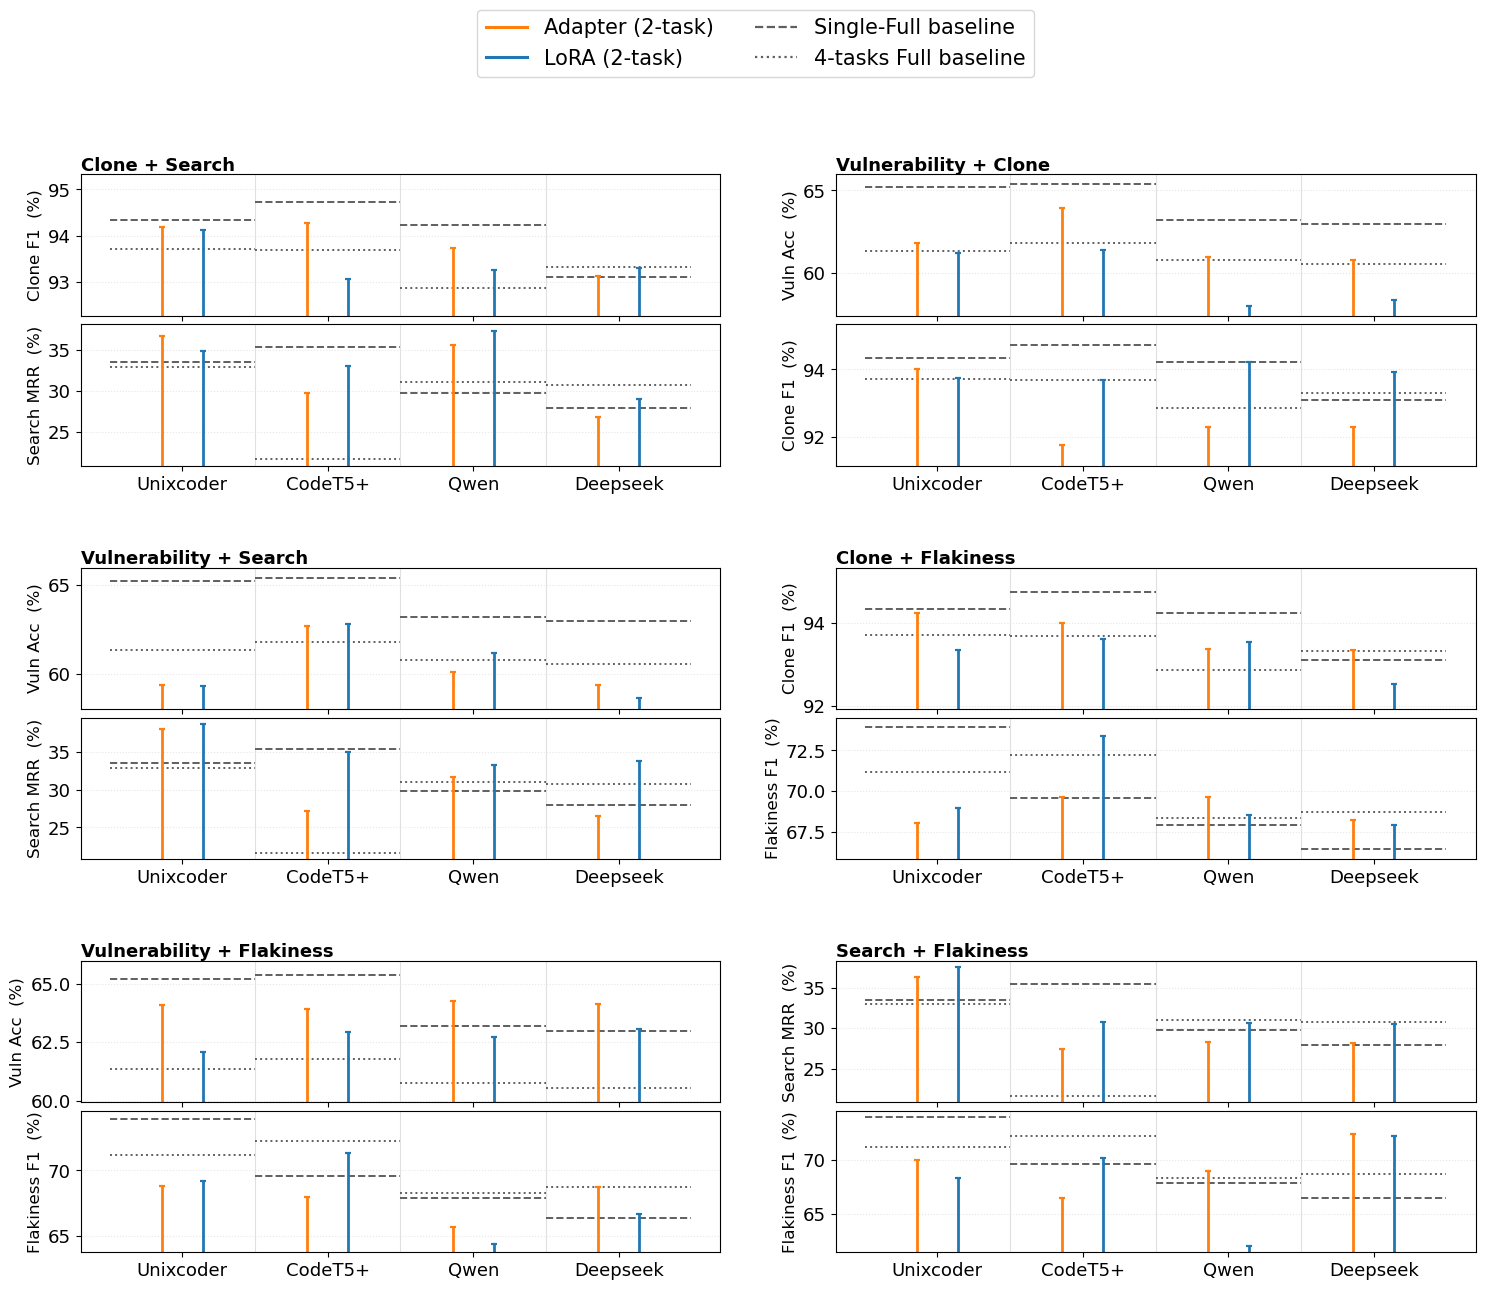

In [4]:
# Fix the "collapsed lines" issue in the Vuln+Clone panel by making y-limits
# use the correct element index (0 for the first task, 1 for the second).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ------------ baselines ------------
SFT_full = {
    "Unixcoder": {"Vuln Acc":65.19, "Clone F1":94.34, "Flakiness F1":73.93, "Search MRR":33.51},
    "CodeT5+":   {"Vuln Acc":65.37, "Clone F1":94.73, "Flakiness F1":69.57, "Search MRR":35.41},
    "Deepseek":  {"Vuln Acc":62.96, "Clone F1":93.10, "Flakiness F1":66.41, "Search MRR":27.92},
    "Qwen":      {"Vuln Acc":63.18, "Clone F1":94.23, "Flakiness F1":67.88, "Search MRR":29.80},
}
MFT_full = {
    "Unixcoder": {"Vuln Acc":61.35, "Clone F1":93.70, "Flakiness F1":71.20, "Search MRR":32.94},
    "CodeT5+":   {"Vuln Acc":61.79, "Clone F1":93.68, "Flakiness F1":72.24, "Search MRR":21.64},
    "Deepseek":  {"Vuln Acc":60.53, "Clone F1":93.31, "Flakiness F1":68.71, "Search MRR":30.70},
    "Qwen":      {"Vuln Acc":60.76, "Clone F1":92.86, "Flakiness F1":68.31, "Search MRR":31.06},
}

# ------------ pairs (same numbers; switched to short keys for models) ------------
vul_flaky = {
    "Unixcoder": {"Single-Full":[65.19,73.93], "4tasks-full":[61.35,71.20],
                  "2tasks-Adapter":[64.09,68.79], "2tasks-LoRA":[62.08,69.16]},
    "CodeT5+": {"Single-Full":[65.37,69.57], "4tasks-full":[61.79,72.24],
                "2tasks-Adapter":[63.91,68.00], "2tasks-LoRA":[62.92,71.29]},
    "Qwen": {"Single-Full":[63.18,67.88], "4tasks-full":[60.76,68.71],
             "2tasks-Adapter":[64.25,65.67], "2tasks-LoRA":[62.74,64.37]},
    "Deepseek": {"Single-Full":[62.96,66.41], "4tasks-full":[60.53,68.71],
                 "2tasks-Adapter":[64.13,68.71], "2tasks-LoRA":[63.07,66.67]}
}

vul_clone = {
    "Unixcoder": {"Single-Full":[65.19,94.34], "4tasks-full":[61.35,93.70],
                  "2tasks-Adapter":[61.79,94.01], "2tasks-LoRA":[61.20,93.73]},
    "CodeT5+": {"Single-Full":[65.37,94.73], "4tasks-full":[61.79,93.68],
                "2tasks-Adapter":[63.95,91.76], "2tasks-LoRA":[61.38,93.68]},
    "Qwen": {"Single-Full":[63.18,94.23], "4tasks-full":[60.76,92.86],
             "2tasks-Adapter":[60.98,92.30], "2tasks-LoRA":[58.02, 94.21]},
    "Deepseek": {"Single-Full":[62.96,93.10], "4tasks-full":[60.53,93.31],
                 "2tasks-Adapter":[60.76,92.30], "2tasks-LoRA":[58.38,93.92]}
}

clone_search = {
    "Unixcoder": {"Single-Full":[SFT_full["Unixcoder"]["Clone F1"], SFT_full["Unixcoder"]["Search MRR"]],
                  "4tasks-full":[MFT_full["Unixcoder"]["Clone F1"], MFT_full["Unixcoder"]["Search MRR"]],
                  "2tasks-Adapter":[94.18, 36.73], "2tasks-LoRA":[94.11, 34.84]},
    "CodeT5+": {"Single-Full":[SFT_full["CodeT5+"]["Clone F1"], SFT_full["CodeT5+"]["Search MRR"]],
                "4tasks-full":[MFT_full["CodeT5+"]["Clone F1"], MFT_full["CodeT5+"]["Search MRR"]],
                "2tasks-Adapter":[94.27, 29.78], "2tasks-LoRA":[93.06, 33.10]},
    "Qwen": {"Single-Full":[SFT_full["Qwen"]["Clone F1"], SFT_full["Qwen"]["Search MRR"]],
             "4tasks-full":[MFT_full["Qwen"]["Clone F1"], MFT_full["Qwen"]["Search MRR"]],
             "2tasks-Adapter":[93.73 , 35.62], "2tasks-LoRA":[93.25 , 37.38]},
    "Deepseek": {"Single-Full":[SFT_full["Deepseek"]["Clone F1"], SFT_full["Deepseek"]["Search MRR"]],
                 "4tasks-full":[MFT_full["Deepseek"]["Clone F1"], MFT_full["Deepseek"]["Search MRR"]],
                 "2tasks-Adapter":[93.13 , 26.76 ], "2tasks-LoRA":[93.29 , 28.98]}
}

vul_search = {
    "Unixcoder": {"Single-Full":[SFT_full["Unixcoder"]["Vuln Acc"], SFT_full["Unixcoder"]["Search MRR"]],
                  "4tasks-full":[MFT_full["Unixcoder"]["Vuln Acc"], MFT_full["Unixcoder"]["Search MRR"]],
                  "2tasks-Adapter":[59.33, 38.04], "2tasks-LoRA":[59.30, 38.74]},
    "CodeT5+": {"Single-Full":[SFT_full["CodeT5+"]["Vuln Acc"], SFT_full["CodeT5+"]["Search MRR"]],
                "4tasks-full":[MFT_full["CodeT5+"]["Vuln Acc"], MFT_full["CodeT5+"]["Search MRR"]],
                "2tasks-Adapter":[62.66, 27.15], "2tasks-LoRA":[62.81, 35.01]},
    "Qwen" : {"Single-Full":[SFT_full["Qwen"]["Vuln Acc"], SFT_full["Qwen"]["Search MRR"]],
              "4tasks-full":[MFT_full["Qwen"]["Vuln Acc"], MFT_full["Qwen"]["Search MRR"]],
              "2tasks-Adapter":[60.08 , 31.75] , "2tasks-LoRA":[61.13 , 33.22]},
    "Deepseek": {"Single-Full":[SFT_full["Deepseek"]["Vuln Acc"], SFT_full["Deepseek"]["Search MRR"]],
                 "4tasks-full":[MFT_full["Deepseek"]["Vuln Acc"], MFT_full["Deepseek"]["Search MRR"]],
                 "2tasks-Adapter":[59.37 , 26.52], "2tasks-LoRA":[58.6 , 33.79]}
}

clone_flaky = {
    "Unixcoder": {"Single-Full":[SFT_full["Unixcoder"]["Clone F1"], SFT_full["Unixcoder"]["Flakiness F1"]],
                  "4tasks-full":[MFT_full["Unixcoder"]["Clone F1"], MFT_full["Unixcoder"]["Flakiness F1"]],
                  "2tasks-Adapter":[94.24, 68.04], "2tasks-LoRA":[93.35, 68.94]},
    "CodeT5+": {"Single-Full":[SFT_full["CodeT5+"]["Clone F1"], SFT_full["CodeT5+"]["Flakiness F1"]],
                "4tasks-full":[MFT_full["CodeT5+"]["Clone F1"], MFT_full["CodeT5+"]["Flakiness F1"]],
                "2tasks-Adapter":[94.00, 69.62], "2tasks-LoRA":[93.62, 73.40]},
    "Qwen": {"Single-Full":[SFT_full["Qwen"]["Clone F1"], SFT_full["Qwen"]["Flakiness F1"]],
             "4tasks-full":[MFT_full["Qwen"]["Clone F1"], MFT_full["Qwen"]["Flakiness F1"]],
             "2tasks-Adapter":[93.36 , 69.66], "2tasks-LoRA":[93.53 , 68.55]},
    "Deepseek": {"Single-Full":[SFT_full["Deepseek"]["Clone F1"], SFT_full["Deepseek"]["Flakiness F1"]],
                 "4tasks-full":[MFT_full["Deepseek"]["Clone F1"], MFT_full["Deepseek"]["Flakiness F1"]],
                 "2tasks-Adapter":[93.34 , 68.24], "2tasks-LoRA":[92.52 , 67.90 ]}
}

search_flaky = {
    "Unixcoder": {"Single-Full":[SFT_full["Unixcoder"]["Search MRR"], SFT_full["Unixcoder"]["Flakiness F1"]],
                  "4tasks-full":[MFT_full["Unixcoder"]["Search MRR"], MFT_full["Unixcoder"]["Flakiness F1"]],
                  "2tasks-Adapter":[36.27, 70.00], "2tasks-LoRA":[37.50, 68.35]},
    "CodeT5+": {"Single-Full":[SFT_full["CodeT5+"]["Search MRR"], SFT_full["CodeT5+"]["Flakiness F1"]],
                "4tasks-full":[MFT_full["CodeT5+"]["Search MRR"], MFT_full["CodeT5+"]["Flakiness F1"]],
                "2tasks-Adapter":[27.45, 66.41], "2tasks-LoRA":[30.74, 70.15]},
    "Qwen" : {"Single-Full":[SFT_full["Qwen"]["Search MRR"], SFT_full["Qwen"]["Flakiness F1"]],
              "4tasks-full":[MFT_full["Qwen"]["Search MRR"], MFT_full["Qwen"]["Flakiness F1"]],
              "2tasks-Adapter":[28.31 , 68.91] , "2tasks-LoRA":[30.60 , 62.02]},
    "Deepseek": {"Single-Full":[SFT_full["Deepseek"]["Search MRR"], SFT_full["Deepseek"]["Flakiness F1"]],
                 "4tasks-full":[MFT_full["Deepseek"]["Search MRR"], MFT_full["Deepseek"]["Flakiness F1"]],
                 "2tasks-Adapter":[28.11 , 72.40] , "2tasks-LoRA":[30.57 , 72.16]}
}

pairs = [
    (clone_search, ["Clone F1","Search MRR"], "Clone + Search"),
    (vul_clone,    ["Vuln Acc","Clone F1"],  "Vulnerability + Clone"),
    (vul_search,   ["Vuln Acc","Search MRR"],"Vulnerability + Search"),
    (clone_flaky,  ["Clone F1","Flakiness F1"], "Clone + Flakiness"),
    (vul_flaky,    ["Vuln Acc","Flakiness F1"], "Vulnerability + Flakiness"),
    (search_flaky, ["Search MRR","Flakiness F1"], "Search + Flakiness"),
]

models = ["Unixcoder","CodeT5+","Qwen","Deepseek"]

def compute_ylims(pair_dict, task, models, idx_in_pair):
    vals = []
    for m in models:
        for src in (SFT_full, MFT_full):
            v = src.get(m, {}).get(task, np.nan)
            if not np.isnan(v): vals.append(v)
        # sticks
        if m in pair_dict:
            for meth in ["2tasks-Adapter","2tasks-LoRA","Multi-Adapter","Multi-LoRA"]:
                vlist = pair_dict[m].get(meth, [])
                j = idx_in_pair  # use actual position (0 or 1)
                if vlist and len(vlist)>j and pd.notna(vlist[j]):
                    vals.append(float(vlist[j]))
    if not vals: return (0, 100)
    lo, hi = min(vals), max(vals)
    pad = max(0.6, 0.05*(hi - lo))
    return max(0, lo - pad), min(100, hi + pad)


def _collect_vals(pair_dict, task, models, idx_in_pair):
    vals = []
    for m in models:
        for src in (SFT_full, MFT_full):
            v = src.get(m, {}).get(task, np.nan)
            if not np.isnan(v):
                vals.append(float(v))
        if m in pair_dict:
            for meth in ["2tasks-Adapter","2tasks-LoRA","Multi-Adapter","Multi-LoRA"]:
                vlist = pair_dict[m].get(meth, [])
                j = idx_in_pair
                if vlist and len(vlist)>j and pd.notna(vlist[j]):
                    vals.append(float(vlist[j]))
    return vals

def _shared_ylim(pair_dict, tasks, models):
    vals_top = _collect_vals(pair_dict, tasks[0], models, idx_in_pair=0)
    vals_bot = _collect_vals(pair_dict, tasks[1], models, idx_in_pair=1)
    vals = vals_top + vals_bot
    if not vals:
        return (0, 100)
    lo, hi = min(vals), max(vals)
    pad = max(0.6, 0.05*(hi - lo))
    return max(0, lo - pad), min(100, hi + pad)




def draw_pair(ax_top, ax_bot, pair_dict, tasks, models):
    x = np.arange(len(models))
    offset = 0.14

    # top
    t = tasks[0]
    lo, hi = compute_ylims(pair_dict, t, models, idx_in_pair=0)
    ax_top.set_ylim(lo, hi)
    for i in range(len(models)-1):
        ax_top.axvline(i+0.5, color="0.88", linewidth=0.8)
    for i, m in enumerate(models):
        bS = SFT_full.get(m, {}).get(t, np.nan); b4 = MFT_full.get(m, {}).get(t, np.nan)
        if not np.isnan(bS): ax_top.hlines(bS, i-0.5, i+0.5, colors="#5f5f5f", linestyles="--", linewidth=1.4)
        if not np.isnan(b4): ax_top.hlines(b4, i-0.5, i+0.5, colors="#5f5f5f", linestyles=":",  linewidth=1.4)
    for i, m in enumerate(models):
        if m not in pair_dict: continue
        for meth, color in [("2tasks-Adapter","#ff7f0e"), ("2tasks-LoRA","#1f77b4"),
                            ("Multi-Adapter","#ff7f0e"), ("Multi-LoRA","#1f77b4")]:
            vlist = pair_dict[m].get(meth, [])
            j = 0
            if vlist and len(vlist)>j and pd.notna(vlist[j]):
                s = float(vlist[j])
                xi = i + (-offset if "Adapter" in meth else +offset)
                ax_top.vlines(xi, lo, s, color=color, linewidth=2.0)
                ax_top.plot([xi],[s], marker="_", markersize=5, color=color, markeredgewidth=1.6)
    ax_top.set_ylabel(f"{t}  (%)")
    ax_top.set_xticks(x); ax_top.set_xticklabels([])
    ax_top.grid(axis="y", linestyle=":", alpha=0.3); ax_top.set_axisbelow(True)

    # bottom
    t = tasks[1]
    lo, hi = compute_ylims(pair_dict, t, models, idx_in_pair=1)
    ax_bot.set_ylim(lo, hi)
    for i in range(len(models)-1):
        ax_bot.axvline(i+0.5, color="0.88", linewidth=0.8)
    for i, m in enumerate(models):
        bS = SFT_full.get(m, {}).get(t, np.nan); b4 = MFT_full.get(m, {}).get(t, np.nan)
        if not np.isnan(bS): ax_bot.hlines(bS, i-0.5, i+0.5, colors="#5f5f5f", linestyles="--", linewidth=1.4)
        if not np.isnan(b4): ax_bot.hlines(b4, i-0.5, i+0.5, colors="#5f5f5f", linestyles=":",  linewidth=1.4)
    for i, m in enumerate(models):
        if m not in pair_dict: continue
        for meth, color in [("2tasks-Adapter","#ff7f0e"), ("2tasks-LoRA","#1f77b4"),
                            ("Multi-Adapter","#ff7f0e"), ("Multi-LoRA","#1f77b4")]:
            vlist = pair_dict[m].get(meth, [])
            j = 1
            if vlist and len(vlist)>j and pd.notna(vlist[j]):
                s = float(vlist[j])
                xi = i + (-offset if "Adapter" in meth else +offset)
                ax_bot.vlines(xi, lo, s, color=color, linewidth=2.0)
                ax_bot.plot([xi],[s], marker="_", markersize=5, color=color, markeredgewidth=1.6)
    ax_bot.set_ylabel(f"{t}  (%)")
    ax_bot.set_xticks(x); ax_bot.set_xticklabels(models, rotation=0)
    ax_bot.grid(axis="y", linestyle=":", alpha=0.3); ax_bot.set_axisbelow(True)

# render the 3×2 grid again
plt.rcParams.update({
    "font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12,
    "xtick.labelsize": 13, "ytick.labelsize": 13, "legend.fontsize": 14,
})
fig = plt.figure(figsize=(18, 14))
outer = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.18)

for idx, (pdata, tks, title) in enumerate(pairs):
    r, c = divmod(idx, 2)
    gs = outer[r, c].subgridspec(2, 1, hspace=0.06)
    ax1 = fig.add_subplot(gs[0,0])
    ax2 = fig.add_subplot(gs[1,0])
    draw_pair(ax1, ax2, pdata, tks, models)
    ax1.set_title(title, loc="left", fontweight="bold", pad=2)

handles = [
    Line2D([0,1],[0,0], color="#ff7f0e", linewidth=2.2, label="Adapter (2-task)"),
    Line2D([0,1],[0,0], color="#1f77b4", linewidth=2.2, label="LoRA (2-task)"),
    Line2D([0,1],[0,0], color="#5f5f5f", linestyle="--", linewidth=1.6, label="Single-Full baseline"),
    Line2D([0,1],[0,0], color="#5f5f5f", linestyle=":",  linewidth=1.6, label="4-tasks Full baseline"),
]
fig.legend(handles, [h.get_label() for h in handles],
           ncol=2, loc="upper center", bbox_to_anchor=(0.5, 1.005),
           frameon=True, fontsize=15)

fig.tight_layout(rect=[0.03, 0.03, 0.97, 0.97])


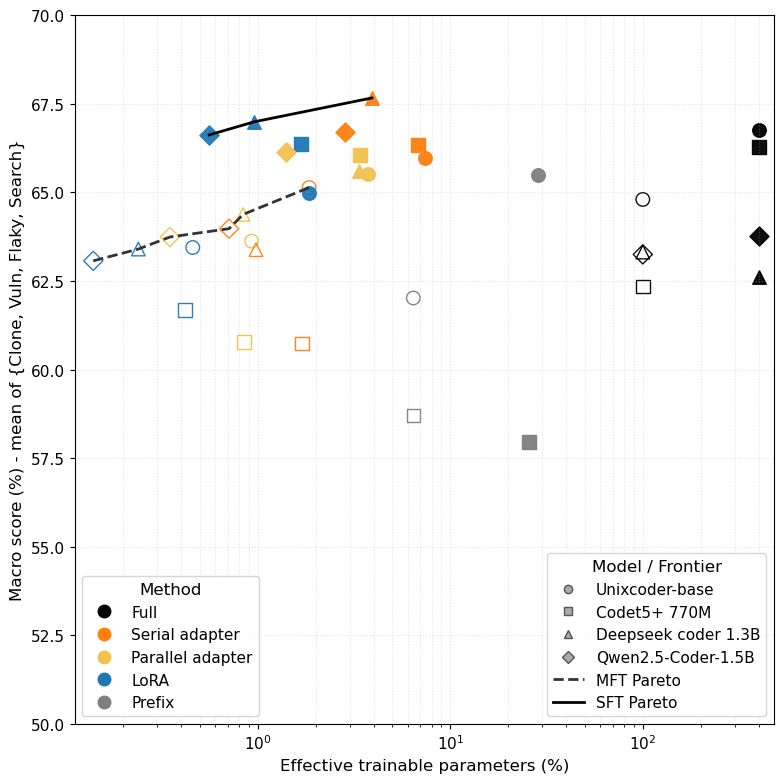

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, FuncFormatter

# ----------------------------
# Recreate the table (MFT + SFT)
# ----------------------------
recs = []
def add(setting, model, method, trainable_pct, clone, vuln, flaky, search):
    recs.append({
        "setting": setting, "model": model, "method": method,
        "trainable_pct": trainable_pct,
        "Clone F1": clone, "Vuln Acc": vuln, "Flakiness F1": flaky, "Search MRR": search
    })

# ---- MFT ----
add("MFT","Unixcoder-base","Full",100.00,93.70,61.35,71.20,32.94)
add("MFT","Unixcoder-base","Serial adapter",1.85,93.79,61.35,71.90,33.49)
add("MFT","Unixcoder-base","Parallel adapter",0.93,92.29,61.05,68.65,32.50)
add("MFT","Unixcoder-base","LoRA",0.46,92.33,60.43,66.20,34.81)
add("MFT","Unixcoder-base","Prefix",6.43,90.85,60.98,65.38,30.86)

add("MFT","Codet5+ 770M","Full",100.00,93.68,61.79,72.24,21.64)
add("MFT","Codet5+ 770M","Serial adapter",1.70,92.28,63.47,69.80,17.40)
add("MFT","Codet5+ 770M","Parallel adapter",0.85,92.24,60.87,70.00,20.01)
add("MFT","Codet5+ 770M","LoRA",0.42,92.56,62.12,69.80,22.21)
add("MFT","Codet5+ 770M","Prefix",6.43,89.23,61.09,68.65,15.83)

add("MFT","Deepseek coder 1.3B","Full",100.00,93.31,60.53,68.71,30.70)
add("MFT","Deepseek coder 1.3B","Serial adapter",0.98,92.57,60.43,69.69,30.83)
add("MFT","Deepseek coder 1.3B","Parallel adapter",0.84,93.72,60.40,70.18,33.20)
add("MFT","Deepseek coder 1.3B","LoRA",0.24,92.31,60.25,67.13,33.90)

add("MFT","Qwen2.5-Coder-1.5B","Full",100.00,92.86,60.76,68.31,31.06)
add("MFT","Qwen2.5-Coder-1.5B","Serial adapter",0.71,92.68,60.87,72.54,29.80)
add("MFT","Qwen2.5-Coder-1.5B","Parallel adapter",0.35,92.17,58.64,72.08,32.06)
add("MFT","Qwen2.5-Coder-1.5B","LoRA",0.14,92.47,57.39,70.97,31.43)

# ---- SFT ----
add("SFT","Unixcoder-base","Full",100.00,94.34,65.19,73.93,33.51)
add("SFT","Unixcoder-base","Serial adapter",1.85,94.71,63.07,69.45,36.68)
add("SFT","Unixcoder-base","Parallel adapter",0.93,94.36,64.86,67.58,35.31)
add("SFT","Unixcoder-base","LoRA",0.46,93.84,62.59,66.22,37.28)
add("SFT","Unixcoder-base","Prefix",7.16,92.75,62.41,68.73,38.10)

add("SFT","Codet5+ 770M","Full",100.00,94.73,65.37,69.57,35.41)
add("SFT","Codet5+ 770M","Serial adapter",1.70,93.90,65.48,68.87,37.13)
add("SFT","Codet5+ 770M","Parallel adapter",0.85,94.41,64.20,69.08,36.47)
add("SFT","Codet5+ 770M","LoRA",0.42,93.99,63.56,70.21,37.70)
add("SFT","Codet5+ 770M","Prefix",6.43,90.35,56.30,56.92,28.27)

add("SFT","Deepseek coder 1.3B","Full",100.00,93.10,62.96,66.41,27.92)
add("SFT","Deepseek coder 1.3B","Serial adapter",0.98,93.38,63.87,71.63,41.76)
add("SFT","Deepseek coder 1.3B","Parallel adapter",0.84,93.50,63.62,68.69,36.55)
add("SFT","Deepseek coder 1.3B","LoRA",0.24,93.75,63.73,66.90,43.57)

add("SFT","Qwen2.5-Coder-1.5B","Full",100.00,94.23,63.18,67.88,29.80)
add("SFT","Qwen2.5-Coder-1.5B","Serial adapter",0.71,94.43,62.70,69.90,39.82)
add("SFT","Qwen2.5-Coder-1.5B","Parallel adapter",0.35,94.08,62.77,70.42,37.26)
add("SFT","Qwen2.5-Coder-1.5B","LoRA",0.14,93.99,62.85,69.82,39.81)

df = pd.DataFrame.from_records(recs)

# ----------------------------
# Build macro scores & effective budgets
# ----------------------------
metrics = ["Clone F1","Vuln Acc","Flakiness F1","Search MRR"]
df["macro"] = df[metrics].mean(axis=1)

# Effective trainable PERCENT (%):
#   MFT = trainable%
#   SFT = 4 × trainable%  (four separate models/heads)
df["eff_pct"] = df.apply(
    lambda r: r["trainable_pct"] if r["setting"]=="MFT" else 4.0 * r["trainable_pct"],
    axis=1
)

# Δ vs Full (macro) within (setting, model)
full_macro = (
    df[df["method"]=="Full"]
    .set_index(["setting","model"])["macro"]
    .to_dict()
)
def delta_macro(row):
    base = full_macro.get((row["setting"], row["model"]), np.nan)
    return np.nan if np.isnan(base) else row["macro"] - base
df["Δmacro_vs_Full"] = df.apply(delta_macro, axis=1)

# ----------------------------
# Styles
# ----------------------------
method_colors = {
    "Full": "#000000",
    "Serial adapter": "#ff7f0e",
    "Parallel adapter": "#f2c14e",
    "LoRA": "#1f77b4",
    "Prefix": "#7f7f7f",
}
model_markers = {
    "Unixcoder-base": "o",
    "Codet5+ 770M": "s",
    "Deepseek coder 1.3B": "^",
    "Qwen2.5-Coder-1.5B": "D",
}

plt.rcParams.update({
    "font.size": 12, "axes.titlesize": 14, "axes.labelsize": 12,
    "xtick.labelsize": 11, "ytick.labelsize": 11, "legend.fontsize": 11,
})

# ----------------------------
# Figure 1: Pareto overlay (MFT & SFT together)
# ----------------------------
fig1 = plt.figure(figsize=(8, 8))
ax = plt.gca()

# Plot MFT (hollow markers) & SFT (filled), colored by method, shaped by model
for setting, fillstyle, alpha in [("MFT","none",0.95), ("SFT","full",0.95)]:
    sub = df[df["setting"]==setting]
    for _, r in sub.iterrows():
        ax.scatter(
            r["eff_pct"], r["macro"],
            s=95,
            facecolors=("none" if fillstyle=="none" else method_colors.get(r["method"], "#444")),
            edgecolors=method_colors.get(r["method"], "#444"),
            marker=model_markers.get(r["model"], "o"),
            linewidths=1.0,
            alpha=alpha,
            label=None
        )

# Pareto frontiers for each setting
def pareto_frontier(xs, ys):
    pts = sorted(zip(xs, ys), key=lambda t: (t[0], -t[1]))
    front, best = [], -np.inf
    for x, y in pts:
        if y > best:
            front.append((x, y)); best = y
    return np.array(front)

for setting, ls, col in [("MFT","--","#333333"), ("SFT","-","#000000")]:
    sub = df[df["setting"]==setting]
    fr = pareto_frontier(sub["eff_pct"].values, sub["macro"].values)
    if len(fr) > 1:
        ax.plot(fr[:,0], fr[:,1], ls=ls, color=col, linewidth=2.0, label=f"{setting} Pareto")

# Formatting
xmin = max(df["eff_pct"].min()*0.8, 0.01)
xmax = df["eff_pct"].max()*1.2
ax.set_xscale("log")
ax.set_xlim(xmin, xmax)
ax.set_ylim(50,70)
ax.grid(True, which="both", linestyle=":", alpha=0.35)
ax.set_xlabel("Effective trainable parameters (%)")
ax.set_ylabel("Macro score (%) - mean of {Clone, Vuln, Flaky, Search}")

# Legends
method_handles = [plt.Line2D([0],[0], color=method_colors[m], marker='o', linestyle='',
                             markersize=9, label=m) for m in ["Full","Serial adapter","Parallel adapter","LoRA","Prefix"]]
model_handles  = [plt.Line2D([0],[0], color="#555555", marker=model_markers[m], linestyle='',
                             markerfacecolor="#aaaaaa", label=m) for m in model_markers]
pareto_handles = [h for h in ax.get_legend_handles_labels()[0] if isinstance(h, plt.Line2D) and h.get_label().endswith("Pareto")]

leg0 = ax.legend(method_handles, [h.get_label() for h in method_handles],
                 loc="lower left", frameon=True, title="Method")
ax.add_artist(leg0)
ax.legend(model_handles + pareto_handles,
          [h.get_label() for h in model_handles] + ["MFT Pareto","SFT Pareto"],
          loc="lower right", frameon=True, title="Model / Frontier")

fig1.tight_layout()
# fig1.savefig("RQ2_Pareto_overlay_effpct.png", dpi=300, bbox_inches="tight")

# ----------------------------
# Figure 2: Method shift (MFT → SFT) on (effective %, mean Δmacro)
# ----------------------------


plt.show()


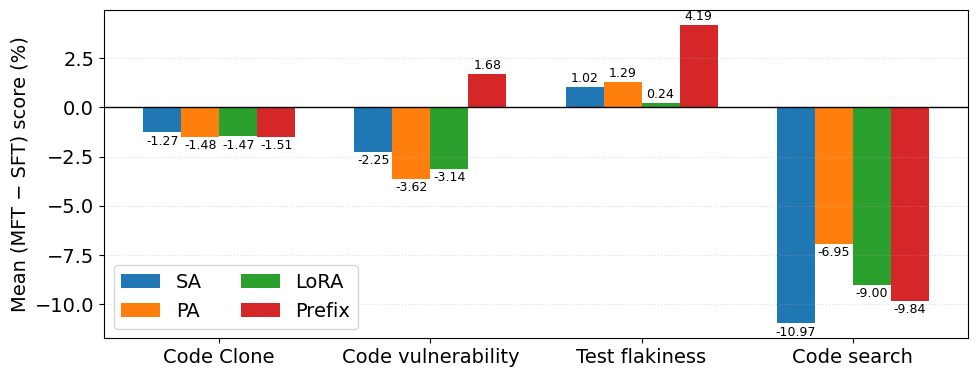

In [15]:
# Build data from the provided table and plot mean (MFT - SFT) score differences by task and method.
# Negative bars = drop in MFT relative to SFT (what the user asked to show).

import numpy as np
import matplotlib.pyplot as plt

# ---------------- Data keyed as: data[setting][model][method][task] = score ----------------
tasks = ["Clone F1", "Vuln Acc", "Flakiness F1", "Search MRR"]
models = ["Unixcoder", "CodeT5+", "Deepseek", "Qwen"]
methods = ["SA","PA","LoRA","Prefix","Full"]  # we'll compute per-PEFT and also show Full for context if needed

MFT = {
    "Unixcoder": {
        "Full":  {"Clone F1":93.70, "Vuln Acc":61.35, "Flakiness F1":71.20, "Search MRR":32.94},
        "SA":    {"Clone F1":93.79, "Vuln Acc":61.35, "Flakiness F1":71.90, "Search MRR":33.49},
        "PA":    {"Clone F1":92.29, "Vuln Acc":61.05, "Flakiness F1":68.65, "Search MRR":32.50},
        "LoRA":  {"Clone F1":92.33, "Vuln Acc":60.43, "Flakiness F1":66.20, "Search MRR":34.81},
        "Prefix":{"Clone F1":90.85, "Vuln Acc":60.98, "Flakiness F1":65.38, "Search MRR":30.86},
    },
    "CodeT5+": {
        "Full":  {"Clone F1":93.68, "Vuln Acc":61.79, "Flakiness F1":72.24, "Search MRR":21.64},
        "SA":    {"Clone F1":92.28, "Vuln Acc":63.47, "Flakiness F1":69.80, "Search MRR":17.40},
        "PA":    {"Clone F1":92.24, "Vuln Acc":60.87, "Flakiness F1":70.00, "Search MRR":20.01},
        "LoRA":  {"Clone F1":92.56, "Vuln Acc":62.12, "Flakiness F1":69.80, "Search MRR":22.21},
        "Prefix":{"Clone F1":89.23, "Vuln Acc":61.09, "Flakiness F1":68.65, "Search MRR":15.83},
    },
    "Deepseek": {
        "Full":  {"Clone F1":93.31, "Vuln Acc":60.53, "Flakiness F1":68.71, "Search MRR":30.70},
        "SA":    {"Clone F1":92.57, "Vuln Acc":60.43, "Flakiness F1":69.69, "Search MRR":30.83},
        "PA":    {"Clone F1":93.72, "Vuln Acc":60.40, "Flakiness F1":70.18, "Search MRR":33.20},
        "LoRA":  {"Clone F1":92.31, "Vuln Acc":60.25, "Flakiness F1":67.13, "Search MRR":33.90},
        # no Prefix
    },
    "Qwen": {
        "Full":  {"Clone F1":92.86, "Vuln Acc":60.76, "Flakiness F1":68.31, "Search MRR":31.06},
        "SA":    {"Clone F1":92.68, "Vuln Acc":60.87, "Flakiness F1":72.54, "Search MRR":29.80},
        "PA":    {"Clone F1":92.17, "Vuln Acc":58.64, "Flakiness F1":72.08, "Search MRR":32.06},
        "LoRA":  {"Clone F1":92.47, "Vuln Acc":57.39, "Flakiness F1":70.97, "Search MRR":31.43},
        # no Prefix
    },
}

SFT = {
    "Unixcoder": {
        "Full":  {"Clone F1":94.34, "Vuln Acc":65.19, "Flakiness F1":73.93, "Search MRR":33.51},
        "SA":    {"Clone F1":94.71, "Vuln Acc":63.07, "Flakiness F1":69.45, "Search MRR":36.68},
        "PA":    {"Clone F1":94.36, "Vuln Acc":64.86, "Flakiness F1":67.58, "Search MRR":35.31},
        "LoRA":  {"Clone F1":93.84, "Vuln Acc":62.59, "Flakiness F1":66.22, "Search MRR":37.28},
        "Prefix":{"Clone F1":92.75, "Vuln Acc":62.41, "Flakiness F1":68.73, "Search MRR":38.10},
    },
    "CodeT5+": {
        "Full":  {"Clone F1":94.73, "Vuln Acc":65.37, "Flakiness F1":69.57, "Search MRR":35.41},
        "SA":    {"Clone F1":93.90, "Vuln Acc":65.48, "Flakiness F1":68.87, "Search MRR":37.13},
        "PA":    {"Clone F1":94.41, "Vuln Acc":64.20, "Flakiness F1":69.08, "Search MRR":36.47},
        "LoRA":  {"Clone F1":93.99, "Vuln Acc":63.56, "Flakiness F1":70.21, "Search MRR":37.70},
        "Prefix":{"Clone F1":90.35, "Vuln Acc":56.30, "Flakiness F1":56.92, "Search MRR":28.27},
    },
    "Deepseek": {
        "Full":  {"Clone F1":93.10, "Vuln Acc":62.96, "Flakiness F1":66.41, "Search MRR":27.92},
        "SA":    {"Clone F1":93.38, "Vuln Acc":63.87, "Flakiness F1":71.63, "Search MRR":41.76},
        "PA":    {"Clone F1":93.50, "Vuln Acc":63.62, "Flakiness F1":68.69, "Search MRR":36.55},
        "LoRA":  {"Clone F1":93.75, "Vuln Acc":63.73, "Flakiness F1":66.90, "Search MRR":43.57},
        # no Prefix
    },
    "Qwen": {
        "Full":  {"Clone F1":94.23, "Vuln Acc":63.18, "Flakiness F1":67.88, "Search MRR":29.80},
        "SA":    {"Clone F1":94.43, "Vuln Acc":62.70, "Flakiness F1":69.90, "Search MRR":39.82},
        "PA":    {"Clone F1":94.08, "Vuln Acc":62.77, "Flakiness F1":70.42, "Search MRR":37.26},
        "LoRA":  {"Clone F1":93.99, "Vuln Acc":62.85, "Flakiness F1":69.82, "Search MRR":39.81},
        # no Prefix
    },
}

# compute mean differences by task for each method: (MFT - SFT) averaged across models where both exist
def mean_diff_by_task(method):
    diffs = {t: [] for t in tasks}
    for model in models:
        if method in MFT.get(model, {}) and method in SFT.get(model, {}):
            for t in tasks:
                if t in MFT[model][method] and t in SFT[model][method]:
                    diffs[t].append(MFT[model][method][t] - SFT[model][method][t])
    # compute means
    return {t: (np.mean(d) if d else np.nan) for t, d in diffs.items()}

methods_to_plot = ["SA","PA","LoRA","Prefix"]  # focus on PEFT methods
diff_means = {m: mean_diff_by_task(m) for m in methods_to_plot}

# Prepare plot data
x_labels = ["Code Clone", "Code vulnerability", "Test flakiness", "Code search"]
task_map = {"Clone F1":"Code Clone","Vuln Acc":"Code vulnerability","Flakiness F1":"Test flakiness","Search MRR":"Code search"}

X = np.arange(len(x_labels))
width = 0.18

fig = plt.figure(figsize=(10,4))
ax = plt.gca()

for i, m in enumerate(methods_to_plot):
    vals = [diff_means[m][k] for k in ["Clone F1","Vuln Acc","Flakiness F1","Search MRR"]]
    bars = ax.bar(X + (i-1.5)*width, vals, width, label=m)
    # label each bar with value rounded
    for b, v in zip(bars, vals):
        if np.isnan(v): continue
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + (0.1 if v>=0 else -0.1),
                f"{v:.2f}", ha="center", va=("bottom" if v>=0 else "top"), fontsize=9)

ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(X); ax.set_xticklabels(x_labels)
ax.set_ylabel("Mean (MFT − SFT) score (%)")
ax.legend(loc="lower left", ncol=2, frameon=True)
ax.grid(axis="y", linestyle=":", alpha=0.4)
plt.rcParams.update({
    "font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14,
    "xtick.labelsize": 14, "ytick.labelsize": 14, "legend.fontsize": 14,
})

plt.tight_layout()
plt.show()

